In [22]:
# Paso 1 — Instalar bibliotecas
!mamba install pandas numpy matplotlib seaborn sqlalchemy pymysql

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, sqlalchemy, pymysql
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.4842000000476838 seconds
All requested packages already installed.


In [23]:
# Paso 2 — Importar bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [26]:
# Paso 3 — Cargar datos

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

<class 'FileNotFoundError'>: [Errno 44] No such file or directory: 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [27]:
# Paso 4 — Exploración inicial

print('=== Tipos de datos ===')
df.info()
print('\n=== Estadísticas descriptivas ===')
display(df.describe())
print('\n=== Valores nulos ===')
display(df.isnull().sum().to_frame('nulos'))

=== Tipos de datos ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   str     
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBil

,tenure,MonthlyCharges,TotalCharges,Churn_Flag
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370
std,24.559481,30.090047,2266.794470,0.441561
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000
max,72.000000,118.750000,8684.800000,1.000000



=== Valores nulos ===


,nulos
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
# Paso 5 — Limpieza de datos

# 1. TotalCharges: viene como string, convertir a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Los 11 registros nulos tienen tenure=0 (clientes nuevos sin pagos aún)
# → imputar con 0, no con la mediana (que inflaría artificialmente sus cargos)
print(f'Registros con TotalCharges nulo: {df["TotalCharges"].isna().sum()}')
print(df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges']])
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. SeniorCitizen: convertir 0/1 → No/Yes para legibilidad
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# 3. Eliminar duplicados
antes = len(df)
df = df.drop_duplicates()
print(f'\nDuplicados eliminados: {antes - len(df)}')
print(f'Shape final: {df.shape}')
print(f'\nNulos restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Registros con TotalCharges nulo: 11
      customerID  tenure  MonthlyCharges
488   4472-LVYGI       0           52.55
753   3115-CZMZD       0           20.25
936   5709-LVOEQ       0           80.85
1082  4367-NUYAO       0           25.75
1340  1371-DWPAZ       0           56.05
3331  7644-OMVMY       0           19.85
3826  3213-VVOLG       0           25.35
4380  2520-SGTTA       0           20.00
5218  2923-ARZLG       0           19.70
6670  4075-WKNIU       0           73.35
6754  2775-SEFEE       0           61.90

Duplicados eliminados: 0
Shape final: (7043, 21)

Nulos restantes:
Series([], dtype: int64)


In [7]:
# Paso 6 — Transformación

# Variable objetivo binaria
df['Churn_Flag'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Segmentación por antigüedad
bins   = [0, 12, 24, 48, 60, 73]
labels = ['0-1 año', '1-2 años', '2-4 años', '4-5 años', '5+ años']
df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

# Segmentación por nivel de cargo mensual
df['Charge_Tier'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 65, 90, 120],
    labels=['Bajo', 'Medio', 'Alto', 'Premium']
)

print('Distribución Tenure_Group:')
print(df['Tenure_Group'].value_counts().sort_index())
print('\nDistribución Charge_Tier:')
print(df['Charge_Tier'].value_counts().sort_index())

Distribución Tenure_Group:
Tenure_Group
0-1 año     2175
1-2 años    1024
2-4 años    1594
4-5 años     832
5+ años     1407
Name: count, dtype: int64

Distribución Charge_Tier:
Charge_Tier
Bajo       1735
Medio      1409
Alto       2160
Premium    1739
Name: count, dtype: int64


In [8]:
# Paso 7 — Análisis estadístico

print('=== Tasa de churn general ===')
churn_rate = df['Churn_Flag'].mean() * 100
print(f'  Churn rate: {churn_rate:.2f}%  '
      f'({df["Churn"].value_counts()["Yes"]} de {len(df)} clientes)\n')

print('=== Métricas clave por estado de Churn ===')
resumen = df.groupby('Churn').agg(
    clientes        = ('customerID',     'count'),
    antiguedad_prom = ('tenure',          'mean'),
    cargo_mens_prom = ('MonthlyCharges',  'mean'),
    cargo_total_prom= ('TotalCharges',    'mean')
).round(2)
display(resumen)

print('\n=== Churn rate por tipo de contrato ===')
contrato = df.groupby('Contract')['Churn_Flag'].agg(
    total='count', churned='sum', churn_rate='mean'
)
contrato['churn_rate'] = (contrato['churn_rate'] * 100).round(1)
display(contrato)

print('\n=== Churn rate por servicio de internet ===')
internet = df.groupby('InternetService')['Churn_Flag'].agg(
    total='count', churned='sum', churn_rate='mean'
)
internet['churn_rate'] = (internet['churn_rate'] * 100).round(1)
display(internet)

print('\n=== Churn rate por grupo de antigüedad ===')
tenure_grp = df.groupby('Tenure_Group', observed=True)['Churn_Flag'].agg(
    total='count', churned='sum', churn_rate='mean'
)
tenure_grp['churn_rate'] = (tenure_grp['churn_rate'] * 100).round(1)
display(tenure_grp)

=== Tasa de churn general ===
  Churn rate: 26.54%  (1869 de 7043 clientes)

=== Métricas clave por estado de Churn ===


,clientes,antiguedad_prom,cargo_mens_prom,cargo_total_prom
Churn,,,,
No,5174,37.57,61.27,2549.91
Yes,1869,17.98,74.44,1531.80



=== Churn rate por tipo de contrato ===


,total,churned,churn_rate
Contract,,,
Month-to-month,3875,1655,42.7
One year,1473,166,11.3
Two year,1695,48,2.8



=== Churn rate por servicio de internet ===


,total,churned,churn_rate
InternetService,,,
DSL,2421,459,19.0
Fiber optic,3096,1297,41.9
No,1526,113,7.4



=== Churn rate por grupo de antigüedad ===


,total,churned,churn_rate
Tenure_Group,,,
0-1 año,2175,1037,47.7
1-2 años,1024,294,28.7
2-4 años,1594,325,20.4
4-5 años,832,120,14.4
5+ años,1407,93,6.6


/tmp/xpython_42/1919186228.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#2C3E7A', '#C0392B'])


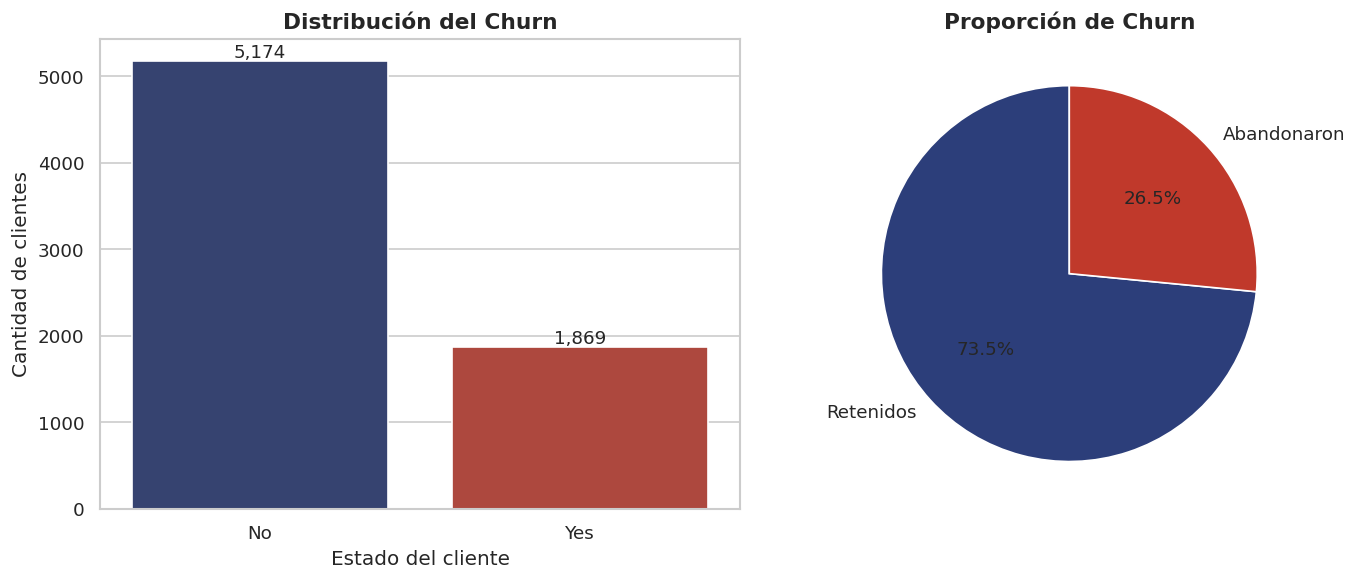

In [9]:
# Visualización 1 — Distribución del Churn

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#2C3E7A', '#C0392B'])
axes[0].set_title('Distribución del Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estado del cliente')
axes[0].set_ylabel('Cantidad de clientes')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=['Retenidos', 'Abandonaron'],
            colors=['#2C3E7A', '#C0392B'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proporción de Churn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

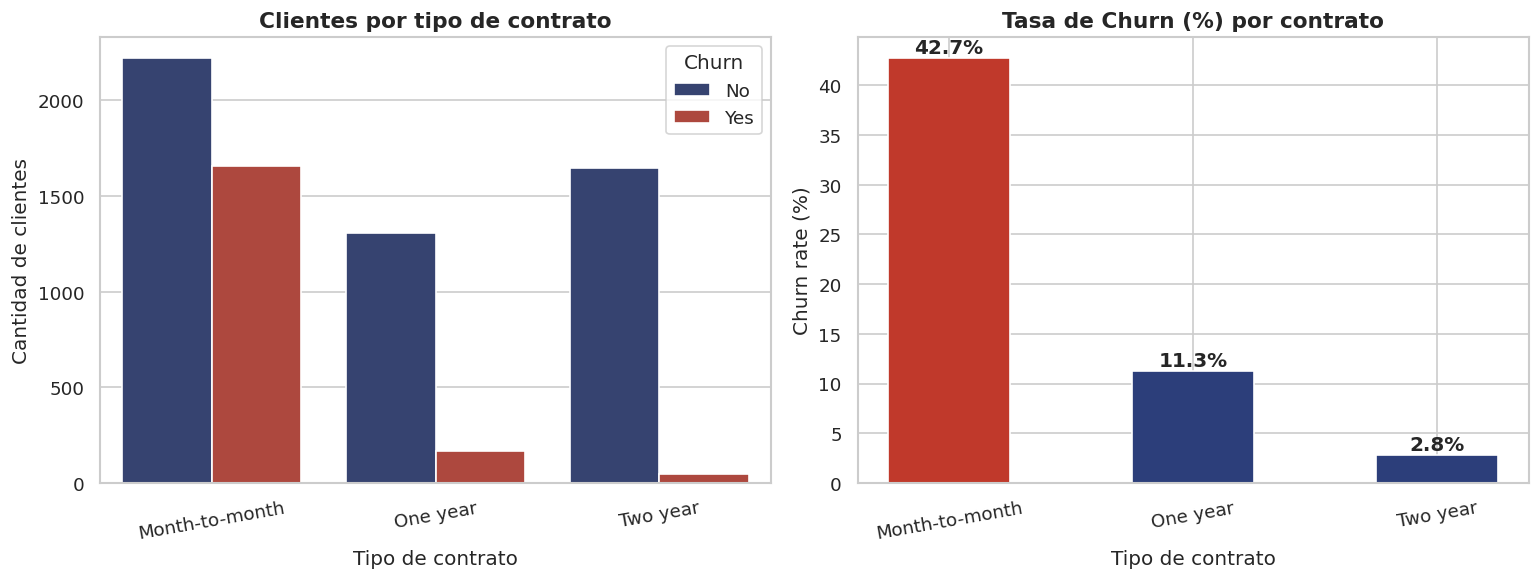

In [10]:
# Visualización 2 — Churn por tipo de contrato

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0],
              palette=['#2C3E7A', '#C0392B'])
axes[0].set_title('Clientes por tipo de contrato', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tipo de contrato')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].tick_params(axis='x', rotation=10)
axes[0].legend(title='Churn')

churn_rate_c = df.groupby('Contract')['Churn_Flag'].mean() * 100
bars = axes[1].bar(churn_rate_c.index, churn_rate_c.values,
                    color=['#C0392B' if v > 20 else '#2C3E7A' for v in churn_rate_c.values],
                    edgecolor='white', width=0.5)
axes[1].set_title('Tasa de Churn (%) por contrato', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tipo de contrato')
axes[1].set_ylabel('Churn rate (%)')
axes[1].tick_params(axis='x', rotation=10)
for bar, v in zip(bars, churn_rate_c.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                  f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/xpython_42/2395114697.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate_t.index, y=churn_rate_t.values, ax=axes[1],


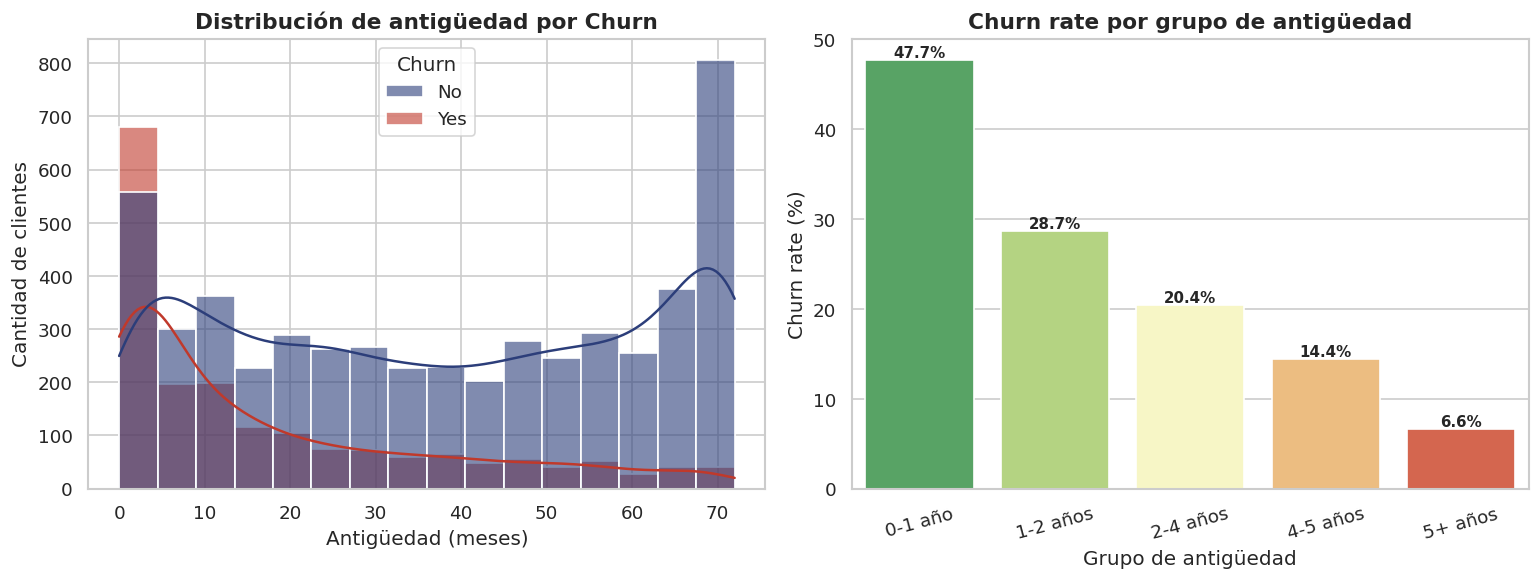

In [11]:
# Visualización 3 — Churn por antigüedad

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0],
             palette=['#2C3E7A', '#C0392B'], alpha=0.6)
axes[0].set_title('Distribución de antigüedad por Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Antigüedad (meses)')
axes[0].set_ylabel('Cantidad de clientes')

churn_rate_t = df.groupby('Tenure_Group', observed=True)['Churn_Flag'].mean() * 100
sns.barplot(x=churn_rate_t.index, y=churn_rate_t.values, ax=axes[1],
            palette='RdYlGn_r')
axes[1].set_title('Churn rate por grupo de antigüedad', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grupo de antigüedad')
axes[1].set_ylabel('Churn rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(churn_rate_t.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/xpython_42/1500976334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0],
/tmp/xpython_42/1500976334.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate_ch.index, y=churn_rate_ch.values, ax=axes[1],


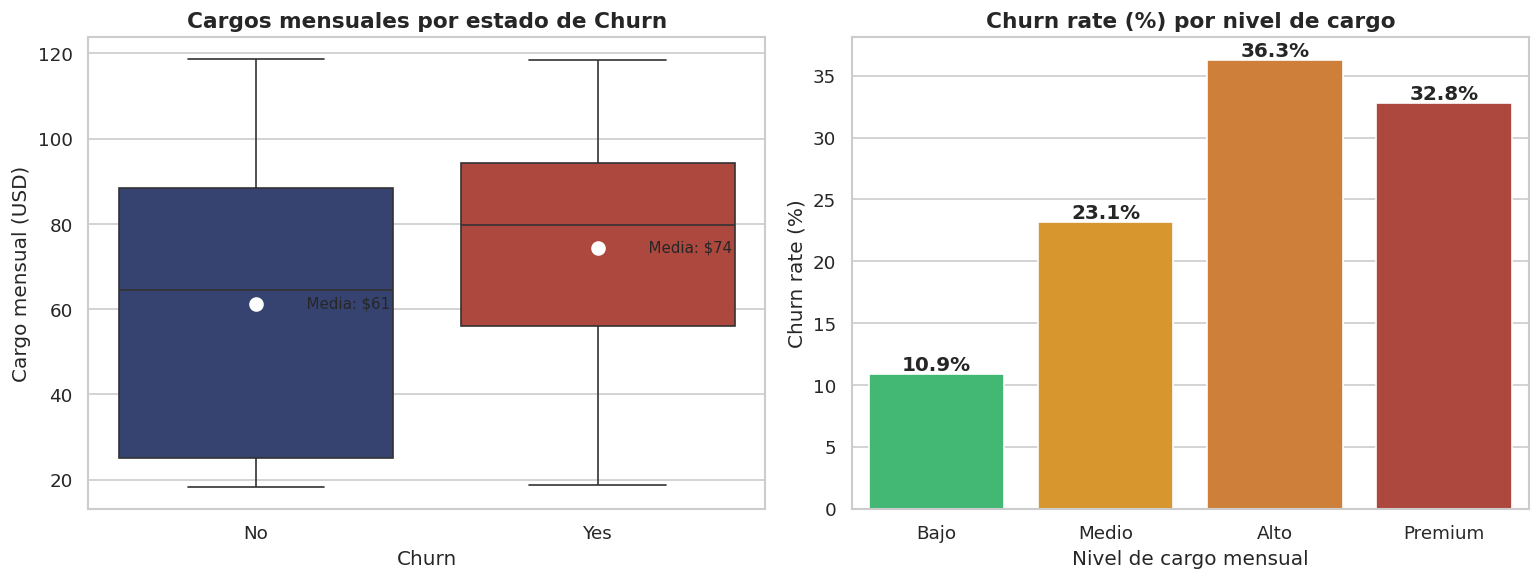

In [12]:
# Visualización 4 — Cargos mensuales por Churn

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0],
            palette=['#2C3E7A', '#C0392B'])
axes[0].set_title('Cargos mensuales por estado de Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cargo mensual (USD)')
for i, group in enumerate(['No', 'Yes']):
    media = df[df['Churn'] == group]['MonthlyCharges'].mean()
    axes[0].scatter(i, media, color='white', zorder=5, s=60)
    axes[0].text(i + 0.12, media, f'  Media: ${media:.0f}', va='center', fontsize=9)

churn_rate_ch = df.groupby('Charge_Tier', observed=True)['Churn_Flag'].mean() * 100
sns.barplot(x=churn_rate_ch.index, y=churn_rate_ch.values, ax=axes[1],
            palette=['#2ecc71', '#f39c12', '#e67e22', '#C0392B'])
axes[1].set_title('Churn rate (%) por nivel de cargo', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nivel de cargo mensual')
axes[1].set_ylabel('Churn rate (%)')
for i, v in enumerate(churn_rate_ch.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

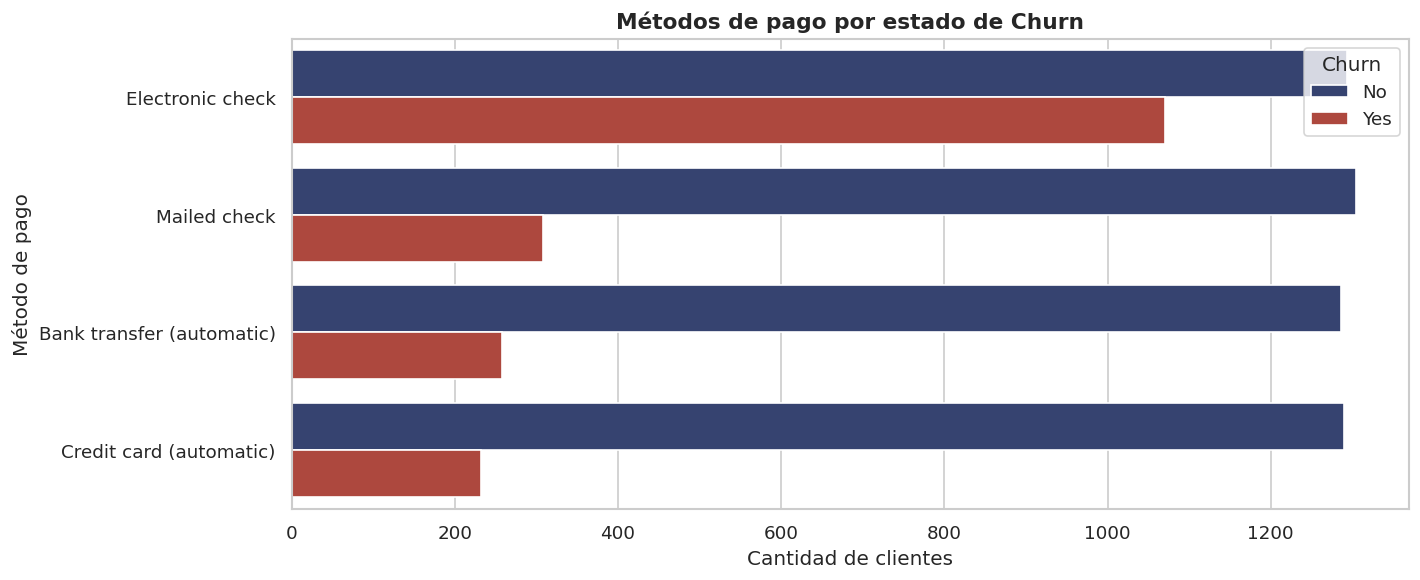

In [13]:
# Visualización 5 — Métodos de pago

fig, ax = plt.subplots(figsize=(12, 5))

sns.countplot(data=df, y='PaymentMethod', hue='Churn', ax=ax,
              palette=['#2C3E7A', '#C0392B'])
ax.set_title('Métodos de pago por estado de Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de clientes')
ax.set_ylabel('Método de pago')
ax.legend(title='Churn')

plt.tight_layout()
plt.show()

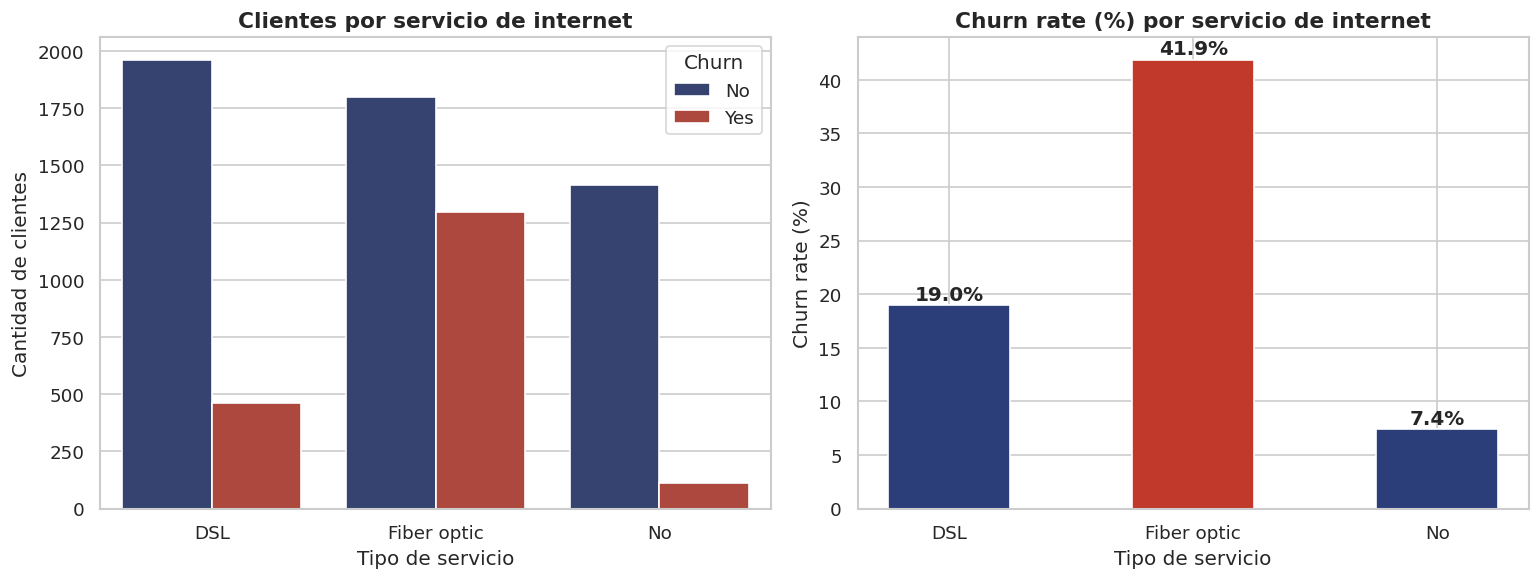

In [14]:
# Visualización 6 — Churn por servicio de Internet (INSIGHT CLAVE)
# Fiber optic tiene un churn del 41.9% vs 19% en DSL y 7.4% sin internet

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0],
              palette=['#2C3E7A', '#C0392B'])
axes[0].set_title('Clientes por servicio de internet', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tipo de servicio')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].legend(title='Churn')

churn_rate_i = df.groupby('InternetService')['Churn_Flag'].mean() * 100
bars = axes[1].bar(churn_rate_i.index, churn_rate_i.values,
                    color=['#C0392B' if v > 25 else '#2C3E7A' for v in churn_rate_i.values],
                    edgecolor='white', width=0.5)
axes[1].set_title('Churn rate (%) por servicio de internet', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tipo de servicio')
axes[1].set_ylabel('Churn rate (%)')
for bar, v in zip(bars, churn_rate_i.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                  f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

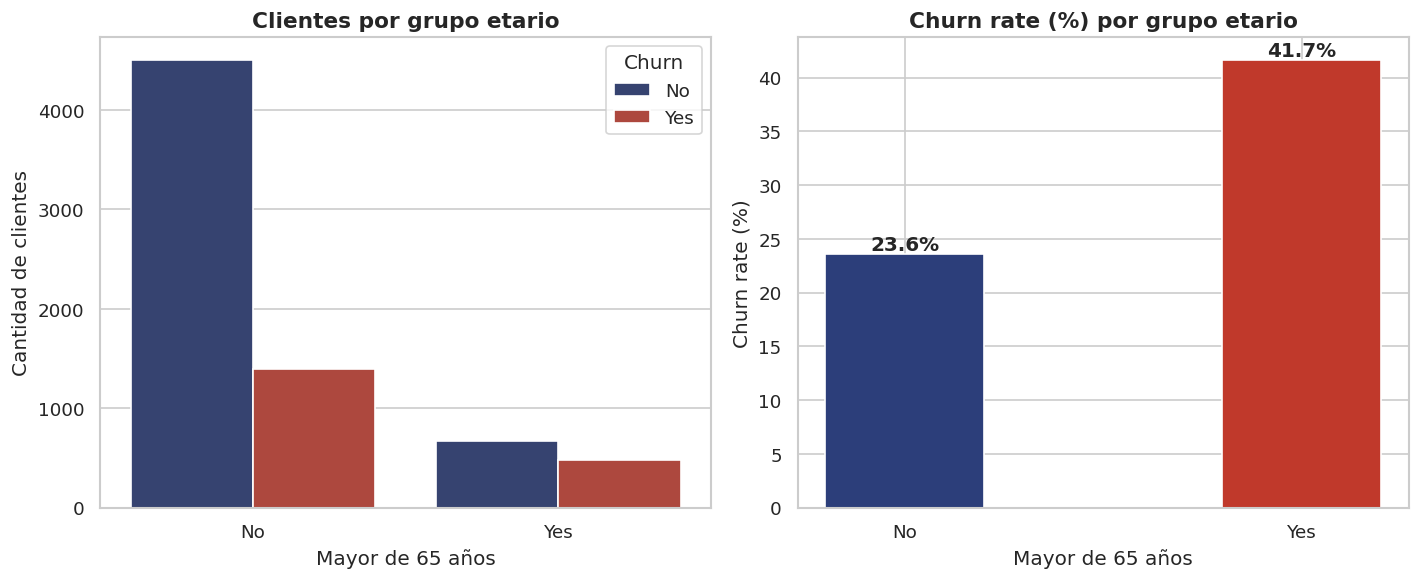

In [15]:
# Visualización 7 — Churn por grupo etario (SeniorCitizen)
# Mayores de 65 años tienen churn del 41.7% vs 23.6% en el resto

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0],
              palette=['#2C3E7A', '#C0392B'])
axes[0].set_title('Clientes por grupo etario', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mayor de 65 años')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].legend(title='Churn')

churn_rate_s = df.groupby('SeniorCitizen')['Churn_Flag'].mean() * 100
bars = axes[1].bar(churn_rate_s.index, churn_rate_s.values,
                    color=['#2C3E7A', '#C0392B'],
                    edgecolor='white', width=0.4)
axes[1].set_title('Churn rate (%) por grupo etario', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mayor de 65 años')
axes[1].set_ylabel('Churn rate (%)')
for i, (label, v) in enumerate(churn_rate_s.items()):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

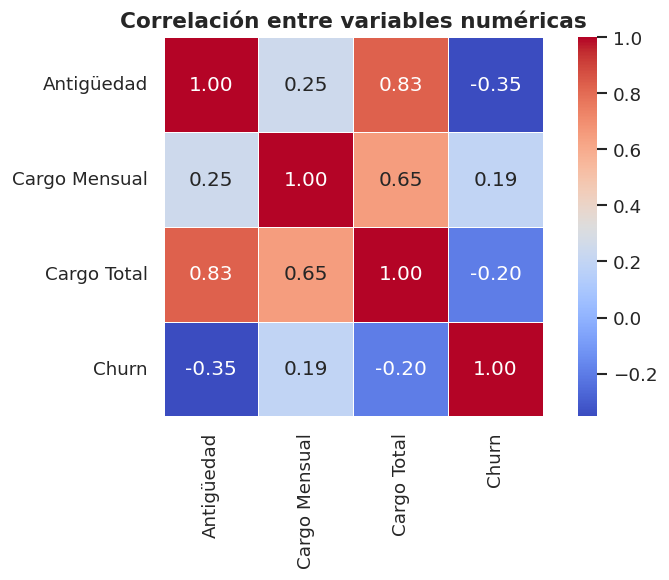

In [16]:
# Visualización 8 — Heatmap de correlación entre variables numéricas

numericas = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Flag']].rename(
    columns={
        'tenure':         'Antigüedad',
        'MonthlyCharges': 'Cargo Mensual',
        'TotalCharges':   'Cargo Total',
        'Churn_Flag':     'Churn'
    }
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, square=True, annot_kws={'size': 12})
ax.set_title('Correlación entre variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Paso 8 — Exportar dataset limpio

df.to_csv('telco_clean.csv', index=False)
print(f'Dataset exportado: {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')

Dataset exportado: 7043 filas, 24 columnas
Columnas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Flag', 'Tenure_Group', 'Charge_Tier']
